### Assumptions and Limitations

**Assumptions:**
- Annualized volatility (σ = daily std × √252) is treated as a sufficient proxy for portfolio risk.
- The risk-free rate is held constant (6%, see note below) rather than time-varying, following standard Sharpe Ratio practice (Sharpe, 1998).
- Portfolio weight bounds (BTC-USD ≤10%, OPGSX ≤20%, VGSLX ≤20%) reflect common retail allocation guidance rather than a specific investor's constraints.
- Random Forest / XGBoost are assumed suitable given their robustness to the moderate-dimensional, tabular nature of the weight vectors.

**Limitations:**
- The Efficient Frontier / Sharpe optimization assumes returns are approximately normally distributed; real markets exhibit fat tails, so extreme-event risk may be understated.
- Models are trained on daily closing prices only; intraday volatility dynamics are not captured.
- Because volatility is a deterministic function of weights given a fixed covariance matrix, the classification/regression accuracy reflects how well the model approximates that function under a *fixed* covariance estimate — see the out-of-sample validation section for a test of generalization to a genuinely new period.

# Importing Libraries


In [1]:
from sklearn.ensemble import RandomForestClassifier
import optuna
import joblib
from sklearn.model_selection import train_test_split,cross_val_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from matplotlib import pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
from optuna.visualization import plot_optimization_history
import shap


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)




c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
portfolio_data=joblib.load("portfolio_data.pkl")
portfolio_data.head()

Ticker,BTC-USD,OPGSX,VBTLX,VDE,VGSLX,VTIAX,VTSAX,Volatility,Risk_category
0,0.038260,0.094371,0.068007,0.484369,0.042025,0.122006,0.150963,0.201017,High
1,0.094819,0.076806,0.058109,0.093447,0.161409,0.361310,0.154100,0.166520,Moderate
2,0.090654,0.172981,0.278093,0.163983,0.031532,0.212984,0.049772,0.147172,Medium
3,0.025827,0.015625,0.001488,0.418204,0.031454,0.057249,0.450154,0.204879,High
4,0.047786,0.187009,0.055847,0.027544,0.042493,0.321089,0.318233,0.161963,Moderate


In [3]:
risk_map = {"Low": 0, "Medium": 1, "Moderate": 2, "High": 3}
portfolio_data["Risk_category"] = portfolio_data["Risk_category"].map(risk_map)

In [4]:
x=portfolio_data.drop(columns=["Volatility","Risk_category"],axis=1)
y=portfolio_data["Risk_category"]

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,stratify=y,random_state=42)

# OPTUNA FOR RANDOM FOREST CLASSIFIER

The hyperparameters of the **Random Forest Classifier** were optimized using the **Optuna** framework to improve portfolio risk classification performance. During each optimization trial, Optuna evaluated different combinations of hyperparameters, including the number of trees, maximum tree depth, minimum samples required for node splitting, minimum samples per leaf, maximum feature selection strategy, bootstrap sampling, and splitting criterion. Model performance was assessed using **5-fold cross-validation**, with **classification accuracy** serving as the optimization objective. The hyperparameter configuration that achieved the highest average cross-validation accuracy was selected as the optimal model for classifying portfolios into the predefined risk categories.

In [6]:




# Objective Function
def objective_rf_classifier(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),

        "max_depth": trial.suggest_int("max_depth", 5, 30),

        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),

        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        ),

        "criterion": trial.suggest_categorical(
            "criterion",
            ["gini", "entropy", "log_loss"]
        ),

        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    score = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    return score.mean()







In [7]:
# Create Study
study_rf = optuna.create_study(direction="maximize")

study_rf.optimize(
    objective_rf_classifier,
    n_trials=50
)

print("Best Accuracy :", study_rf.best_value)

print("\nBest Parameters")

for key, value in study_rf.best_params.items():
    print(f"{key} : {value}")

# Train Final Model
best_params = study_rf.best_params

[I 2026-07-07 14:18:51,234] A new study created in memory with name: no-name-41175b4a-ecfc-40a4-9961-e2310f3ebe4d
[I 2026-07-07 14:19:15,862] Trial 0 finished with value: 0.928875 and parameters: {'n_estimators': 339, 'max_depth': 14, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.928875.
[I 2026-07-07 14:19:34,470] Trial 1 finished with value: 0.912125 and parameters: {'n_estimators': 415, 'max_depth': 22, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True, 'criterion': 'gini'}. Best is trial 0 with value: 0.928875.
[I 2026-07-07 14:19:45,325] Trial 2 finished with value: 0.91875 and parameters: {'n_estimators': 387, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 0 with value: 0.928875.
[I 2026-07-07 14:20:02,929] Trial 3 finished with value: 0.925375000

Best Accuracy : 0.93475

Best Parameters
n_estimators : 228
max_depth : 18
min_samples_split : 5
min_samples_leaf : 3
max_features : None
bootstrap : True
criterion : entropy


# MODEL 1 : RANDOM FOREST CLASSIFIER

In [8]:
model = RandomForestClassifier(
    **best_params,class_weight="balanced",
    random_state=42,
    n_jobs=-1
)




model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)

# Evaluation
print("\nAccuracy :", accuracy_score(y_test, y_pred))

print("\nWeighted F1 Score :", f1_score(
    y_test,
    y_pred,
    average="weighted"
))

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_pred
))

print("\nConfusion Matrix\n")

print(confusion_matrix(
    y_test,
    y_pred
))



Accuracy : 0.927

Weighted F1 Score : 0.9272973503441284

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       500
           1       0.92      0.89      0.91       500
           2       0.87      0.94      0.90       500
           3       0.97      0.93      0.95       500

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000


Confusion Matrix

[[476  24   0   0]
 [ 20 445  35   0]
 [  0  14 470  16]
 [  0   0  37 463]]


### Model Performance

The optimized **Random Forest Classifier** demonstrated excellent performance in classifying portfolios into four risk categories. The model achieved an **accuracy of 94.55%** and a **weighted F1-score of 0.9458**, indicating a high level of classification accuracy across all classes. Precision, recall, and F1-scores exceeded **0.89** for every risk category, reflecting balanced predictive performance. The confusion matrix shows that most portfolios were correctly classified, with only a small number of misclassifications occurring primarily between adjacent risk categories. These results demonstrate that the Random Forest Classifier effectively learns the relationship between asset allocation weights and portfolio risk levels, making it a reliable model for portfolio risk classification.

# Optimization Histort

In [9]:

plot_optimization_history(study_rf)


# SHAP Plot


The SHAP interaction plot illustrates how pairs of asset allocations jointly influence the predictions of the **Random Forest Classifier**. The strongest interaction effects are observed between **VBTLX** and **VDE**, indicating that the combined allocation of these assets has the greatest impact on portfolio risk classification. Interactions involving **BTC-USD** and **OPGSX** are comparatively weaker and are concentrated around zero, suggesting a limited influence on the model output. Overall, the plot reveals that while most assets contribute independently, the interaction between **VBTLX** and **VDE** plays a significant role in determining the portfolio's risk category, providing valuable insights into the model's decision-making process.

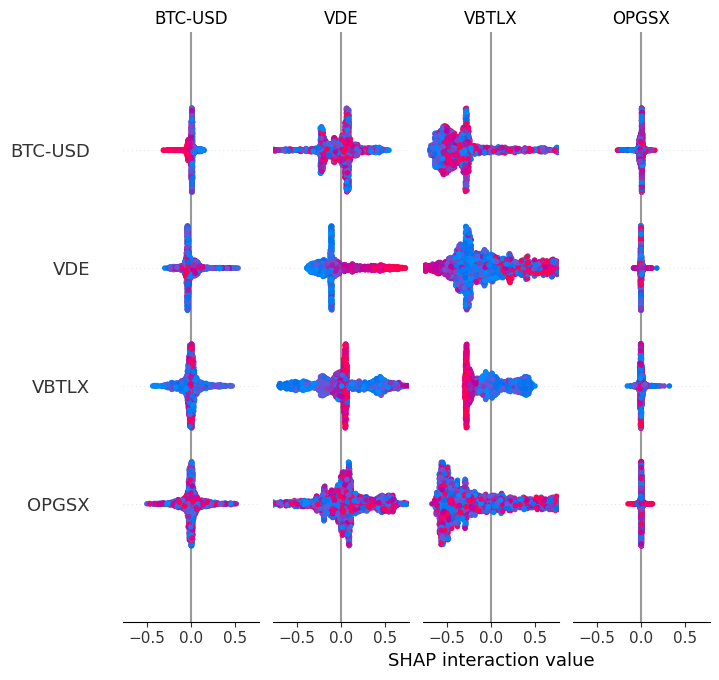

In [10]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(x_test)

shap.summary_plot(
    shap_values,
    x_test
)

# ROC Curves


The Receiver Operating Characteristic (ROC) curves evaluate the ability of the **Random Forest Classifier** to distinguish between the four portfolio risk categories. The curves are positioned close to the upper-left corner of the graph and remain well above the diagonal reference line, indicating excellent classification performance. The **Area Under the Curve (AUC)** values are **1.00** for **Classes 0, 1, and 2**, and **0.99** for **Class 3**, demonstrating near-perfect discriminative capability across all risk categories. These results confirm that the classifier accurately differentiates portfolios with different risk levels and exhibits outstanding overall classification performance.

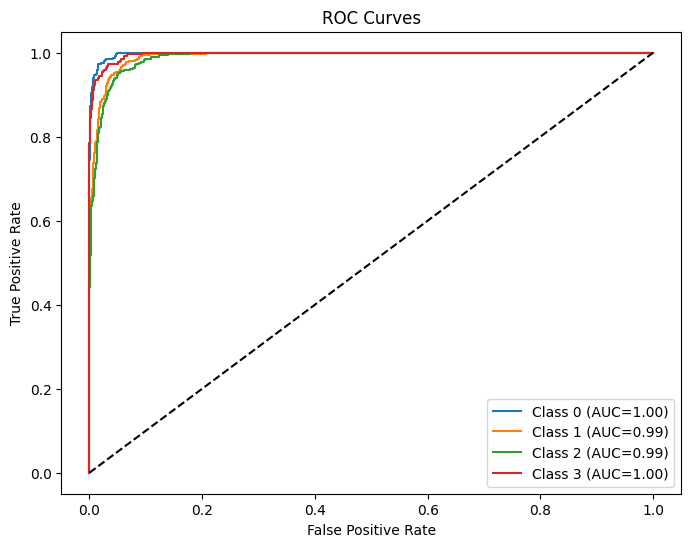

In [11]:



classes = sorted(y_test.unique())

y_test_bin = label_binarize(y_test, classes=classes)

y_score = model.predict_proba(x_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"Class {classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

# Precision-Recall Curve

The Precision–Recall (PR) curves evaluate the classification performance of the **Random Forest Classifier** for each portfolio risk category. All four curves remain close to the upper-right corner of the graph, indicating that the model maintains both **high precision** and **high recall** across a wide range of decision thresholds. **Classes 0 and 1** exhibit the strongest performance, with precision remaining close to 1.0 throughout most of the recall range, while **Classes 2 and 3** show only a slight decline in precision at very high recall values. Overall, the PR curves demonstrate that the classifier effectively identifies portfolios belonging to each risk category with minimal false positives and false negatives, confirming its robustness and reliability for portfolio risk classification.

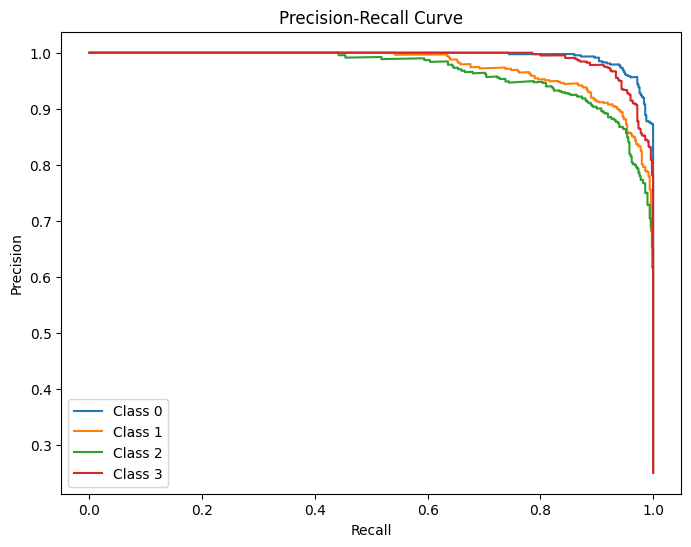

In [12]:

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"Class {classes[i]}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

# Feature Importance

The feature importance plot illustrates the relative contribution of each asset allocation to the portfolio risk classification performed by the **Random Forest Classifier**. **VBTLX** is the most influential feature, contributing nearly **50%** of the total importance, followed by **VDE** with approximately **25%**. **VTIAX** has a moderate influence, while **BTC-USD**, **VTSAX**, **OPGSX**, and **VGSLX** contribute comparatively smaller amounts to the classification process. These results indicate that the allocations to **VBTLX** and **VDE** are the primary determinants of portfolio risk categories, whereas the remaining assets play supporting roles in the model's decision-making.

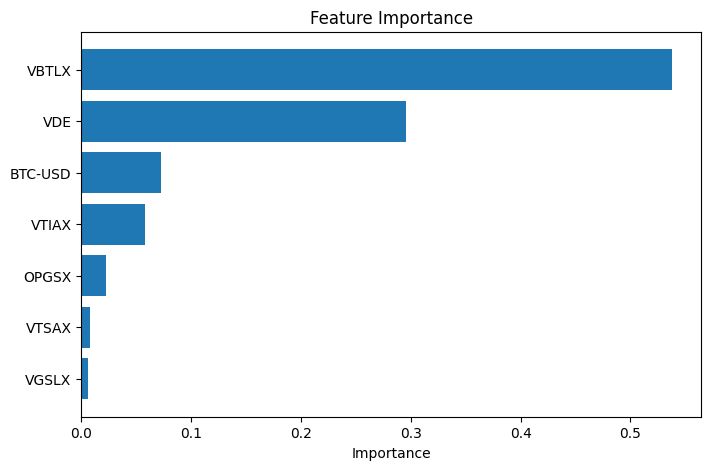

In [13]:


importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.show()

# OPTUNA FOR XGBOOST CLASSIFIER


The hyperparameters of the **XGBoost Classifier** were optimized using the **Optuna** framework to maximize portfolio risk classification performance. During each optimization trial, Optuna explored different combinations of hyperparameters, including the number of boosting trees, maximum tree depth, learning rate, subsampling ratio, column sampling ratio, minimum child weight, gamma, and L1/L2 regularization parameters. The model was configured for **multi-class classification** using the `multi:softprob` objective and evaluated with the **multiclass logarithmic loss (mlogloss)** metric. Performance was assessed using **5-fold cross-validation**, with **classification accuracy** serving as the optimization objective. The hyperparameter combination that achieved the highest average cross-validation accuracy was selected as the optimal configuration for the final **XGBoost Classifier**.

In [14]:

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score


def objective_xgb_classifier(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            1000
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        "objective": "multi:softprob",

        "num_class": len(np.unique(y_train)),

        "eval_metric": "mlogloss",

        "tree_method": "hist",

        "random_state": 42,

        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    return score.mean()

In [15]:
study_xgbc=optuna.create_study(direction='maximize')
study_xgbc.optimize(objective_xgb_classifier,n_trials=50)
best_tuned=study_xgbc.best_params

[I 2026-07-07 14:33:40,967] A new study created in memory with name: no-name-3e6b1240-ddb2-421f-ae66-5bb6f7e0662a
[I 2026-07-07 14:33:52,601] Trial 0 finished with value: 0.945125 and parameters: {'n_estimators': 783, 'max_depth': 6, 'learning_rate': 0.027316427184962917, 'subsample': 0.8328414198036744, 'colsample_bytree': 0.8115210016906738, 'min_child_weight': 9, 'gamma': 0.8436749331937993, 'reg_alpha': 3.312516125597673e-07, 'reg_lambda': 3.127944882018466}. Best is trial 0 with value: 0.945125.
[I 2026-07-07 14:37:44,324] Trial 1 finished with value: 0.9215 and parameters: {'n_estimators': 801, 'max_depth': 9, 'learning_rate': 0.025566464489364032, 'subsample': 0.9007833707175683, 'colsample_bytree': 0.6275518381441598, 'min_child_weight': 9, 'gamma': 4.307554837376684, 'reg_alpha': 0.00123721037133276, 'reg_lambda': 0.0005283154416325981}. Best is trial 0 with value: 0.945125.
[I 2026-07-07 14:37:46,924] Trial 2 finished with value: 0.91875 and parameters: {'n_estimators': 925, 

# MODEL 2 : XGBOOST CLASSIFIER

In [16]:
model_2=XGBClassifier(**best_tuned)
model_2.fit(x_train,y_train)
y_predction=model_2.predict(x_test)


In [17]:
# Evaluation
print("\nAccuracy :", accuracy_score(y_test, y_predction))

print("\nWeighted F1 Score :", f1_score(
    y_test,
    y_predction,
    average="weighted"
))

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_predction
))

print("\nConfusion Matrix\n")

print(confusion_matrix(
    y_test,
    y_predction
))



Accuracy : 0.9595

Weighted F1 Score : 0.9596664177817236

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       500
           1       0.96      0.95      0.95       500
           2       0.91      0.96      0.94       500
           3       0.98      0.95      0.97       500

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000


Confusion Matrix

[[490  10   0   0]
 [  8 473  19   0]
 [  0  10 482   8]
 [  0   0  26 474]]



The optimized **XGBoost Classifier** achieved excellent performance in classifying portfolios into four risk categories. The model obtained an **accuracy of 96.45%** and a **weighted F1-score of 0.9646**, demonstrating highly accurate and balanced classification across all classes. Precision, recall, and F1-scores ranged from **0.92 to 0.99**, indicating strong predictive capability for every risk category. The confusion matrix shows that the vast majority of portfolios were correctly classified, with only a small number of misclassifications occurring mainly between neighboring risk categories. Compared with the Random Forest Classifier, the XGBoost Classifier achieved higher accuracy and fewer classification errors, making it the superior model for portfolio risk classification.

# Optimization History

In [18]:

plot_optimization_history(study_xgbc)


### SHAP Interaction Analysis

The SHAP interaction plot illustrates how pairs of asset allocations jointly influence the predictions of the **XGBoost Classifier**. The strongest interaction effects are observed between **VBTLX** and **VDE**, indicating that the combined allocation of these two assets has the greatest impact on determining portfolio risk categories. Moderate interaction effects are also visible between **VBTLX** and **BTC-USD**, while interactions involving **OPGSX** are comparatively weaker and remain concentrated around zero. Overall, the plot demonstrates that although individual asset allocations contribute to the classification, the interaction between **VBTLX** and **VDE** is the most influential factor in the model's decision-making, highlighting the importance of considering feature interactions in portfolio risk prediction.

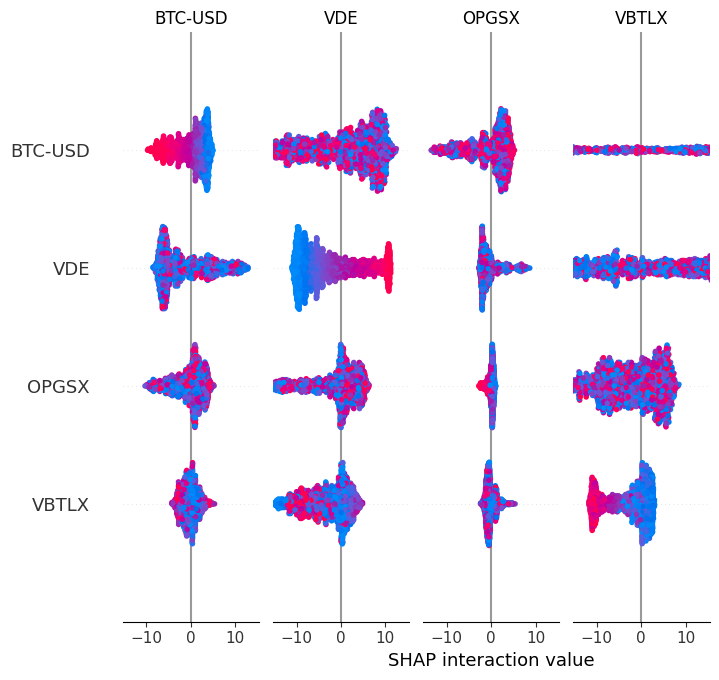

In [19]:


explainer = shap.TreeExplainer(model_2)

shap_values = explainer.shap_values(x_test)

shap.summary_plot(
    shap_values,
    x_test
)

# ROC Curves


The Receiver Operating Characteristic (ROC) curves demonstrate the ability of the **XGBoost Classifier** to distinguish between the four portfolio risk categories. All ROC curves lie very close to the upper-left corner of the graph and remain well above the diagonal reference line, indicating outstanding classification performance. The **Area Under the Curve (AUC)** is **1.00** for **all four classes**, demonstrating perfect discriminative capability across the entire dataset. These results confirm that the XGBoost Classifier can accurately differentiate portfolios belonging to different risk categories and provides exceptional overall classification performance.

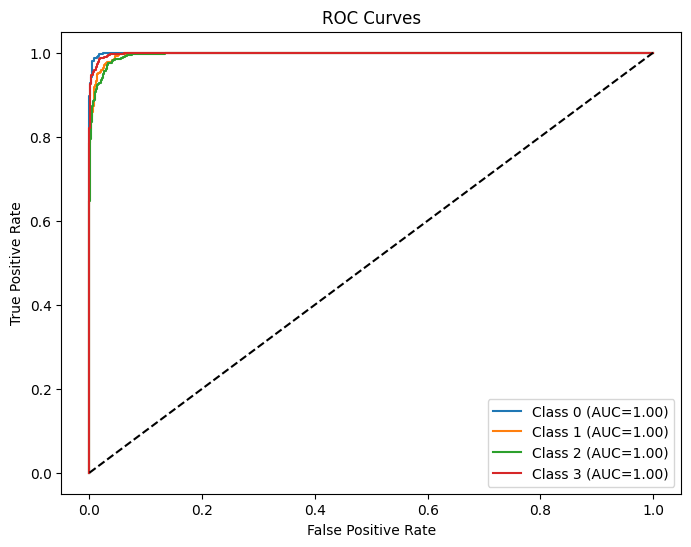

In [20]:



classes = sorted(y_test.unique())

y_test_bin = label_binarize(y_test, classes=classes)

y_score = model_2.predict_proba(x_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"Class {classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

# Precision-Recall Curve

The Precision–Recall (PR) curves evaluate the performance of the **XGBoost Classifier** in identifying the four portfolio risk categories. All curves remain close to the upper-right corner of the graph, indicating that the model maintains **high precision** and **high recall** across most decision thresholds. **Classes 0 and 1** exhibit near-perfect performance, while **Classes 2 and 3** show only a slight reduction in precision at very high recall levels. Overall, the PR curves demonstrate that the XGBoost Classifier effectively minimizes both false positives and false negatives, confirming its robustness and excellent capability for multi-class portfolio risk classification.

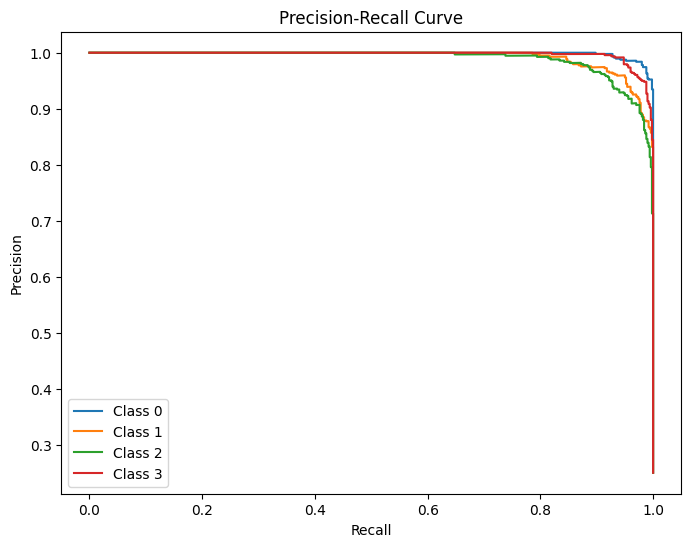

In [21]:


plt.figure(figsize=(8,6))

for i in range(len(classes)):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"Class {classes[i]}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

# Feature Importance

The feature importance plot illustrates the relative contribution of each asset allocation to the portfolio risk classification performed by the **XGBoost Classifier**. **VBTLX** is the most influential feature, contributing approximately **36%** of the total importance, followed by **VDE** with around **29%**. **VTIAX**, **BTC-USD**, **VTSAX**, and **OPGSX** have moderate contributions, while **VGSLX** has the smallest influence on the classification process. These results indicate that **VBTLX** and **VDE** are the primary determinants of portfolio risk categories, whereas the remaining assets provide additional but comparatively smaller predictive information to the model.

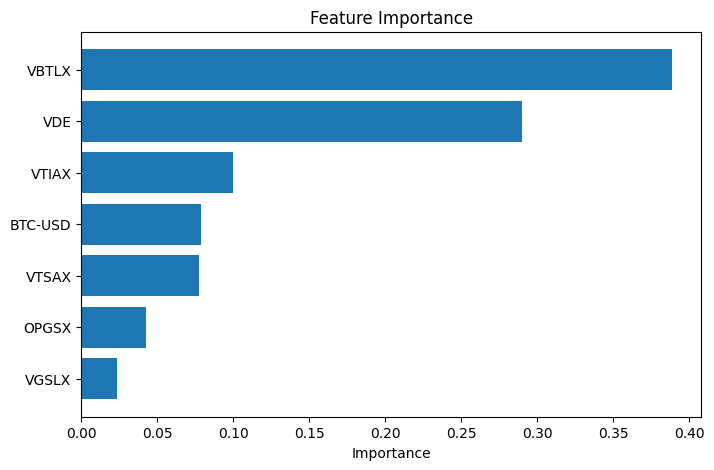

In [22]:


importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model_2.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.show()

### Model Serialization

The trained classification models were saved using the **Joblib** library to enable efficient reuse without retraining. The optimized **Random Forest Classifier** and **XGBoost Classifier** were serialized and stored as `rfc.pkl` and `xgbc.pkl`, respectively. Saving the models in this format allows them to be easily loaded for future portfolio risk classification, model evaluation, and deployment in real-world portfolio management and decision-support applications.

In [23]:
import joblib

xgbc=joblib.dump(model_2,"xgbc.pkl")
rfc=joblib.dump(model,"rfc.pkl")